# Run adaptive immune system with noisy pMHCs

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy import special
from math import erf
import numba as nb
#import nbkode
import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
import os
from sklearn.feature_selection import mutual_info_classif

plt.style.use('/Users/ObinnaUkogu/Desktop/custom.mplstyle')
%config InlineBackend.figure_format = 'retina'

## (1) Define simulation parameters

In [2]:
# Define simulation parameters

# antigens
a1_0 = 100_000
a2 = 50_000_000
a1_max = 0.4*a2
b_a1 = 10
t1 = 10
d_a1 = 3.8*10**(-4) # proxy for virulence
T_a1 = 10

P2 = 1000
b0_P1 = 0.001
b1_P1 = 0.00001
tau_P1 = 0.1
sigma_P1 = 1 # noise scaling in pMHC
#d_P1 = 24*np.log(2)/3.5 # consumption from engagement with TCR
t2 = 3 # dissociation time
n, m = 4, 2

# cells
N0 = 1000
Treg0 = 10000 # initial Tregs
g_NE_max = 0.36
g_NM_max = 0.12
b_E_max = 2.0
g_ME_max = 0 #4.0
g_EM_max = 0.036

k_E = 10**(-11)*(6.0221408*10**23)*50*10**(-6)
k_M = k_E
d_E_max = 2.5
g_T_max = 4
d_T_max = 6

# cytokines
b_c1 = 1000*3600*24
b_c2 = 10 #b_c1/100
f_T = 3*10**(7)*3000*3600*24/((6.0221408*10**23)*50*10**(-6))
k_c1 = 10**(-14)*(6.0221408*10**23)*50*10**(-6)
k_c2_a = 10**(-14)*(6.0221408*10**23)*50*10**(-6)
tau_c = 5/24
I_c1 = 0
I_c2 = 0

# set initial state
init_state = np.array([a1_0, N0, 0, 0, 0, Treg0]) #a1, N, E, cM, eM, T

# activation threshold
mu_theta = 10_000_000
sigma_theta = np.log((mu_theta*t1**n +t2**n)/(mu_theta*t1**m + t2**m))/10

## (2) Define functions for simulations ##

In [3]:
# Define functions for simulations
@nb.vectorize([nb.float64(nb.float64)])
def verf(x):
    return erf(x)

@nb.njit
def hl_u(x,k):
    return (x**1)/(k**1 + x**1)

@nb.njit
def a_stim(t1,a1):
    return (a1/a2*t1**n +t2**n)/(a1/a2*t1**m + t2**m)

@nb.njit
def p_A(t1,a1):
    
    return 1/2 + verf(np.log(a_stim(t1,a1)/a_stim(t1,mu_theta))/np.sqrt(2*sigma_theta**2))/2

@nb.njit
def c2_ss(a1, E):
    
    return E*b_c2*tau_c

@nb.njit
def P1(a1,E):
    
    mu = (b0_P1 + b1_P1*c2_ss(a1, E))*a1*tau_P1
    Gamma = np.random.normal(loc = mu, scale = sigma_P1*np.sqrt(np.maximum(0,2*mu/tau_P1)))

    return mu, np.maximum(0, Gamma)

@nb.njit
def c1_ss(a1, E, T):
    
    return (E*b_c1*p_A(t1,a1) + I_c1)/(T*f_T + 1/tau_c)

@nb.njit
def g_NE(P,T):
    
    return g_NE_max

@nb.njit
def g_NM(P,T):
    
    return g_NM_max

@nb.njit
def b_E(P, T):
    
    return b_E_max

@nb.njit
def b_T(P, T):
    
    return g_T_max

@nb.njit
def g_ME(a1,E,T):

    return g_ME_max*(hl_u(c1_ss(a1,E, T),k_M))

@nb.njit
def g_EM(P,T):
    
    return g_EM_max

@nb.njit
def d_E(a1,E,T):
    
    return d_E_max*(1-hl_u(c1_ss(a1,E, T), k_E))

@nb.njit
def d_T(P,T):
    
    return 0#(1-hl_u(c1_ss(a1,E,T),k_T))/tau_T

# define dynamics
@nb.njit
def state_dyn(t, z, b_a1, t1, d_a1, T_a1, P_vec):
    
    
    a1, N, E, cM, eM, T = z
    
    P = P1(a1,E)[0] # set to 0 for noiseless, 1 for noise
    #P_vec[np.argmax(P_vec == -999)] = P # (1) uncomment to debug noise
    
    return np.asarray([a1*b_a1*(1- a1/a1_max - t/T_a1) - d_a1*a1*E,\
            -(g_NE(P,T)+g_NM(P,T))*N*p_A(t1,a1),\
            g_NE(P,T)*N*p_A(t1,a1) + cM*g_ME(P,E,T) +  E*(b_E(P,T) - g_EM(P,T) - d_E(P,E,T)), \
            g_NM(P,T)*N*p_A(t1,a1) - cM*g_ME(P,E,T), \
            E*g_EM(P,T),\
            0*T*(b_T(P,T) - d_T(P,T))])

In [4]:
print('c_1/E = '+str(b_c1/(Treg0*f_T+1/tau_c)))
print('c_2/E = '+str(b_c2*tau_c))
print('k_E = '+str(k_E))
print('f_T = '+str(f_T))

c_1/E = 11703399.54236066
c_2/E = 2.0833333333333335
k_E = 301107039.99999994
f_T = 0.0002582470340115595


## (3) Vary parameters and run simulations ##

In [5]:
# Run single simulation and plot outputs
duration = 20
steps = 10**3 # grid size for numerical odes
dt = duration/steps
ts = np.linspace(0, duration, steps + 1)

b_a1 = 10
t1 = 10
d_a1 = 3.8*10**(-4) # proxy for virulence
T_a1 = 10
P_vec = np.zeros(shape=1) + -999 # (2) set shape to 50_000 to debug noise
noise_list = []

states = solve_ivp(state_dyn, [0, duration], init_state,
                dense_output=True, args=[b_a1, t1, d_a1, T_a1, P_vec]).sol(ts).T

# states = nbkode.RungeKutta45(state_dyn, t0 = 0, y0 = init_state, 
#                              params = [b_a1, t1, d_a1, T_a1]).run(ts)[1]

a1, N, E, cM, eM, T = states[:,0], states[:,1], states[:,2], states[:,3], states[:,4], states[:,5]

In [6]:
# # (3) Inspect noise
# P_vec[P_vec != -999].shape
# plt.plot(P_vec[P_vec != -999])
# #plt.ylim(0,1000)

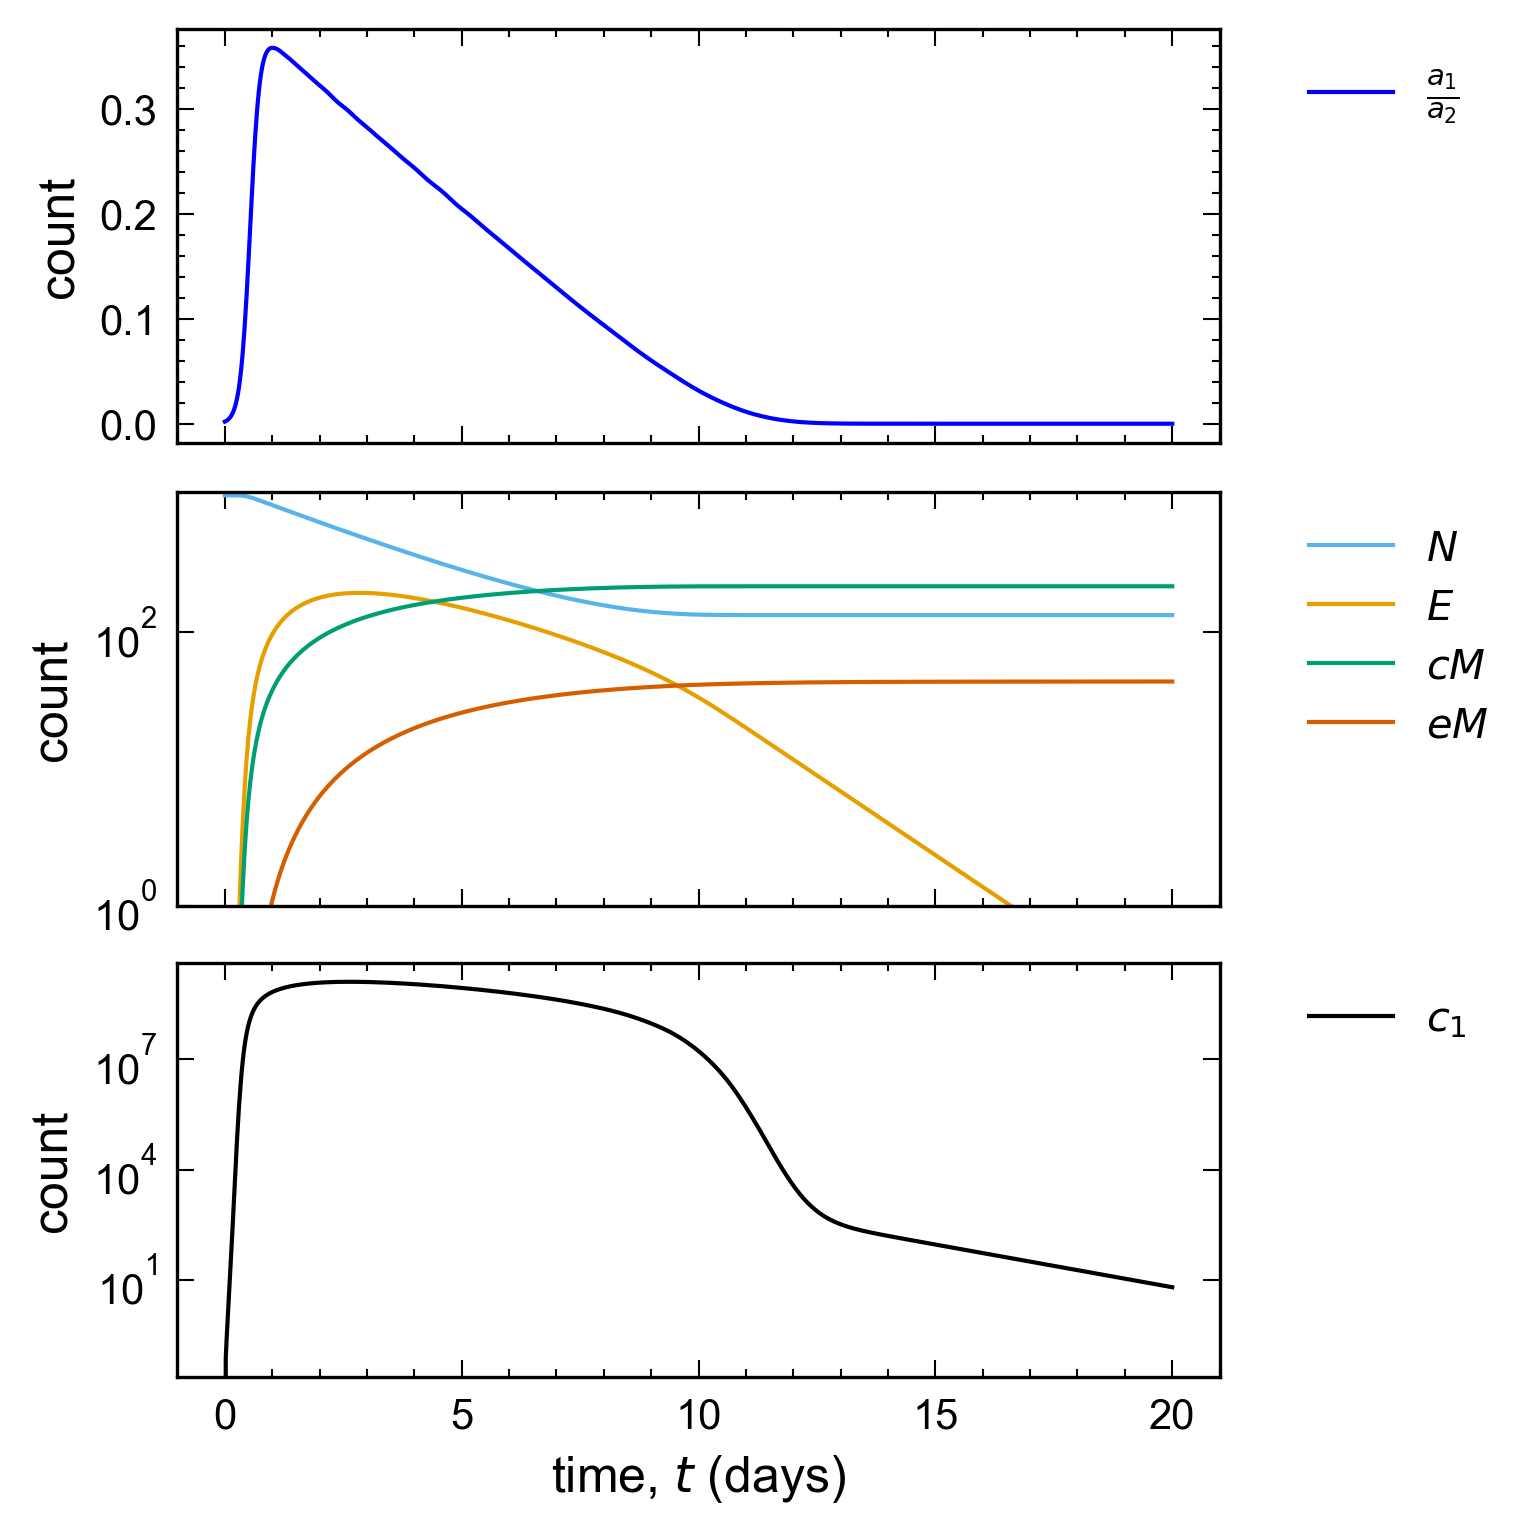

In [7]:
# Plot outputs
fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = True, figsize=(5,5))
ax1.plot(ts, a1/a2, 'b', label = r'$\frac{a_1}{a_2}$')
#ax1.plot(ts, P1.py_func(a1, E)[0], 'k', label = r'$[p_1MHC]$')
ax1.set(ylabel='count')
ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax2.plot(ts, N, label = r'$N$')
ax2.plot(ts, E, label = r'$E$')
ax2.plot(ts, cM, label = r'$cM$')
ax2.plot(ts, eM, label = r'$eM$')
ax2.set(ylabel='count')
ax2.set_ylim(1,)
ax2.semilogy()
ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax3.plot(ts, c1_ss.py_func(a1, E, T),'k-', label = r'$c_1$')
#ax3.plot(ts, c1_ss(P1.py_func(a1, E)[0], E, T)/k_E,'k-', label = r'$\frac{c_1}{k_E}$')
#ax3.plot(ts, c2_ss(a1,E),'k-.', label = r'$c_2$')
ax3.set(xlabel=r'time, $t$ (days)', ylabel='count')
ax3.semilogy()
ax3.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

fig.savefig('virus-effector dynamics.png', dpi=150)

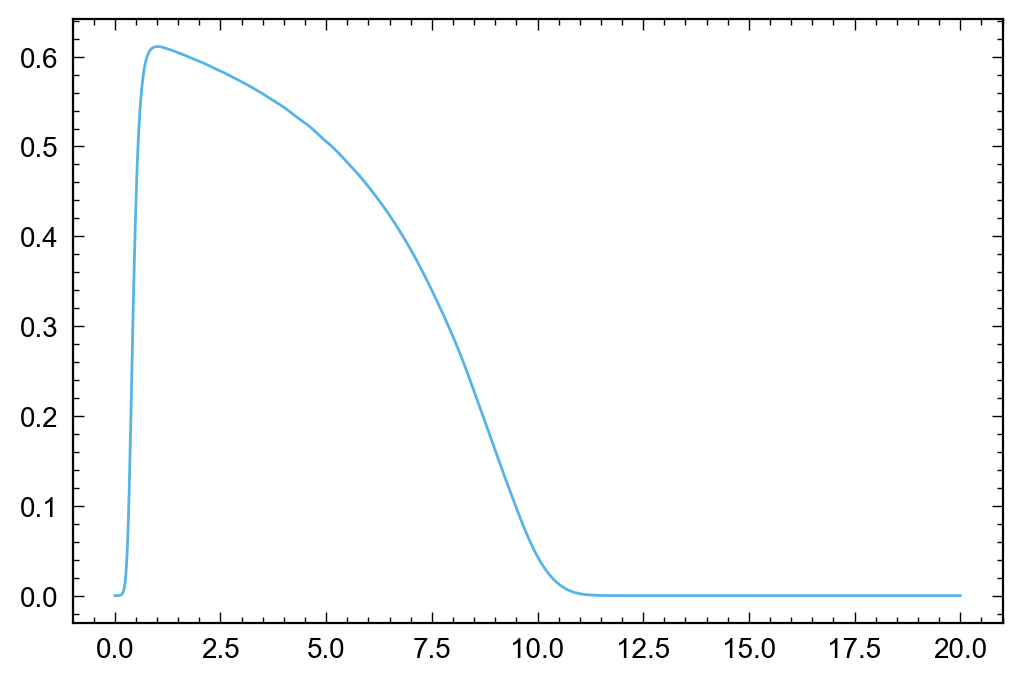

In [8]:
c1_ss(a1[-1], E[-1], T[-1])
plt.plot(ts,p_A(t1,a1))

In [9]:
#print(c1_ss(P1.py_func(a1, E)[0], E, T)[N < 1]/k_E)
print(c2_ss(a1, E)[np.argmax(E)])
print(np.amax(E))
print(cM[np.argmax(E)])
print(P1.py_func(a1, E)[0][np.argmax(E)])
print((k_c1 + P1.py_func(a1, E)[0][np.argmax(E)])*(Treg0*f_T + 1/tau_c)*k_E*(d_E_max - b_E_max + g_EM_max)/((b_E_max-g_EM_max)*b_c1*P1.py_func(a1, E)[0][np.argmax(E)]))
print(P1.py_func(a1, E)[0][100])

404.1120667041284
193.97379201798162
124.45566957184113
7275.380891330074
297.6227070774639
7619.123858482701


In [10]:
# b_c1/(Treg0*f_T+1/tau_c)
# (k_c1 + P1.py_func(a1, E)[0][np.argmax(E)])*(Treg0*f_T + 1/tau_c)*np.sqrt((k_E*(d_E_max - b_E_max + g_EM_max))**2 \
#  - 4*(b_E_max-g_EM_max)*k_E*g_NE_max*N[np.argmax(E)]*p_A(t1,a1)*b_c1*(P1.py_func(a1, E)[0][np.argmax(E)]**2)/((k_c1 + P1.py_func(a1, E)[0][np.argmax(E)])*(Treg0*f_T + 1/tau_c))) \
# /(2*b_c1*P1.py_func(a1, E)[0][np.argmax(E)]*(b_E_max-g_EM_max))

## (4) Invesitigate sloppy parameters in the model

In [11]:
# Evaluate sensitivity equations in sloppy models
Et =  lambda t: interp1d(ts,E)(t).item()
Mt = lambda t: interp1d(ts,cM+eM)(t).item()
Nt = lambda t: interp1d(ts,N)(t).item()
Tt = lambda t: interp1d(ts,T)(t).item()
a1t = lambda t: interp1d(ts,a1)(t).item()

n_sloppy = 18
init_sloppy = np.zeros(n_sloppy)

def sloppy_dyn_E(t, z, b_a1, t1, d_a1, T_a1):
    
    
    dE_g_NE, dE_mu, dE_sigma, dE_g_ME, dE_k_M, dE_b_E, dE_g_EM, dE_d_E, dE_k_E,\
    dE_g_NcM, dE_a2, dE_b1_P1, dE_tau_P1, dE_T, dE_f_T, dE_b_c1, dE_b_c2, dE_tau_c = z
    
    P = P1(a1t(t),Et(t))[1]
    
    return np.asarray([Nt(t)*p_A(t1,a1t(t)),
                       Nt(t)*g_NE(P,Tt(t))*np.exp(-((a_stim(t1,a1t(t)-a_stim(t1,mu_theta))/(np.sqrt(2)*sigma_theta)))**2)*(-1)*mu_theta*(t2**n*t1**m - t2**m*t1**n)/(t1**m*mu_theta + t2**m*a2)/(t1**n*mu_theta/a2 + t2**m),
                       Nt(t)*g_NE(P,Tt(t))*np.exp(-((a_stim(t1,a1t(t)-a_stim(t1,mu_theta))/(np.sqrt(2)*sigma_theta)))**2)*(a_stim(t1,a1t(t))-a_stim(t1,mu_theta))/(np.sqrt(2)*sigma_theta),
                       Mt(t)*g_ME(P,Et(t),Tt(t)),
                       0, #-Mt(t)*g_ME(P,Et(t),Tt(t))*2*k_M/(k_M**2 + c1_ss(P, Et(t), Tt(t))**2),
                       Et(t)*b_E(P,Tt(t)),
                       -Et(t)*g_EM(P,Tt(t)),
                       -Et(t)*d_E(P,Et(t),Tt(t)),
                       Et(t)*d_E(P,Et(t),Tt(t))*2*k_E/(k_M**2 + c1_ss(a1t(t), Et(t), Tt(t))**2),
                       0,
                       0, #b0_P1*a1t(t)*tau_P1*Nt(t)*g_NE(P,Tt(t))*p_A(t1,a1t(t)),
                       0, #b1_P1*c2_ss(a1t(t), Et(t))*a1t(t)*tau_P1*Nt(t)*g_NE(P,Tt(t))*p_A(t1,a1t(t)),
                       0, #P*Nt(t)*g_NE(P,Tt(t))*p_A(t1,a1t(t)),
                       Et(t)*d_E(P,Et(t),Tt(t))*2*c1_ss(a1t(t), Et(t), Tt(t))**2/(k_E**2 + c1_ss(a1t(t), Et(t), Tt(t))**2)*Tt(t)*f_T/(Tt(t)*f_T + 1/tau_c),
                       Et(t)*d_E(P,Et(t),Tt(t))*2*c1_ss(a1t(t), Et(t), Tt(t))**2/(k_E**2 + c1_ss(a1t(t), Et(t), Tt(t))**2)*Tt(t)*f_T/(Tt(t)*f_T + 1/tau_c),
                       - Et(t)*d_E(P,Et(t),Tt(t))*2*c1_ss(a1t(t), Et(t), Tt(t))**2/(k_E**2 + c1_ss(a1t(t), Et(t), Tt(t))**2),
                       0,
                       - Et(t)*d_E(P,Et(t),Tt(t))*2*c1_ss(a1t(t), Et(t), Tt(t))**2/(k_E**2 + c1_ss(a1t(t), Et(t), Tt(t))**2)*Tt(t)*f_T/(Tt(t)*f_T + 1/tau_c)])

def sloppy_dyn_M(t, z, b_a1, t1, d_a1, T_a1):
    
    
    dM_g_NE, dM_mu, dM_sigma, dM_g_ME, dM_k_M, dM_b_E, dM_g_EM, dM_d_E, dM_k_E,\
    dM_g_NM, dM_a2, dM_b1_P1, dM_tau_P1, dM_T, dM_f_T, dM_b_c1, dM_b_c2, dM_tau_c= z
    
    P = P1(a1t(t),Et(t))[1]
    
    return np.asarray([0,
                       Nt(t)*g_NM(P,Tt(t))*np.exp(-((a_stim(t1,a1t(t)-a_stim(t1,mu_theta))/(np.sqrt(2)*sigma_theta)))**2)*(-1)*mu_theta*(t2**n*t1**m - t2**m*t1**n)/(t1**m*mu_theta + t2**m*a2)/(t1**n*mu_theta/a2 + t2**m),
                       Nt(t)*g_NM(P,Tt(t))*np.exp(-((a_stim(t1,a1t(t)-a_stim(t1,mu_theta))/(np.sqrt(2)*sigma_theta)))**2)*(a_stim(t1,a1t(t))-a_stim(t1,mu_theta))/(np.sqrt(2)*sigma_theta),
                       -Mt(t)*g_ME(P,Et(t),Tt(t)),
                       0, #Mt(t)*g_ME(P,Et(t),Tt(t))*2*k_M/(k_M**2 + c1_ss(P, Et(t), Tt(t))**2),
                       0,
                       Et(t)*g_EM(P,Tt(t)),
                       0,
                       0,
                       Nt(t)*g_NM(P,Tt(t))*p_A(t1,a1t(t)),
                       0, #b0_P1*a1t(t)*tau_P1*Nt(t)*g_NM(P,Tt(t))*p_A(t1,a1t(t)),
                       0, #b1_P1*c2_ss(a1t(t), Et(t))*a1t(t)*tau_P1*Nt(t)*g_NM(P,Tt(t))*p_A(t1,a1t(t)),
                       0, #-P*Nt(t)*g_NM(P,Tt(t))*p_A(t1,a1t(t)),
                       0, #Mt(t)*g_ME(P,Et(t),Tt(t))*2*c1_ss(P, Et(t), Tt(t))**2/(k_M**2 + c1_ss(P, Et(t), Tt(t))**2)*Tt(t)*f_T/(Tt(t)*f_T + 1/tau_c) ,
                       0, #Mt(t)*g_ME(P,Et(t),Tt(t))*2*c1_ss(P, Et(t), Tt(t))**2/(k_M**2 + c1_ss(P, Et(t), Tt(t))**2)*Tt(t)*f_T/(Tt(t)*f_T + 1/tau_c) ,
                       0,#-Mt(t)*g_ME(P,Et(t),Tt(t))*2*c1_ss(P, Et(t), Tt(t))**2/(k_M**2 + c1_ss(P, Et(t), Tt(t))**2),
                       0, #b1_P1*c2_ss(a1t(t), Et(t))*a1t(t)*tau_P1*Nt(t)*g_NM(P,Tt(t))*p_A(t1,a1t(t)),
                       0]) #-Mt(t)*g_ME(P,Et(t),Tt(t))*2*c1_ss(P, Et(t), Tt(t))**2/(k_M**2 + c1_ss(P, Et(t), Tt(t))**2)*Tt(t)*f_T/(Tt(t)*f_T + 1/tau_c) + b1_P1*c2_ss(a1t(t), Et(t))*a1t(t)*tau_P1*Nt(t)*g_NM(P,Tt(t))*p_A(t1,a1t(t))])


sloppy_E =  solve_ivp(sloppy_dyn_E, [0, duration], init_sloppy,
                dense_output=True, args=[b_a1, t1, d_a1, T_a1]).sol(ts).T

sloppy_M =  solve_ivp(sloppy_dyn_M, [0, duration], init_sloppy,
                dense_output=True, args=[b_a1, t1, d_a1, T_a1]).sol(ts).T

Text(0.5, 0.98, 'Eigenvalues of Hessian matrix')

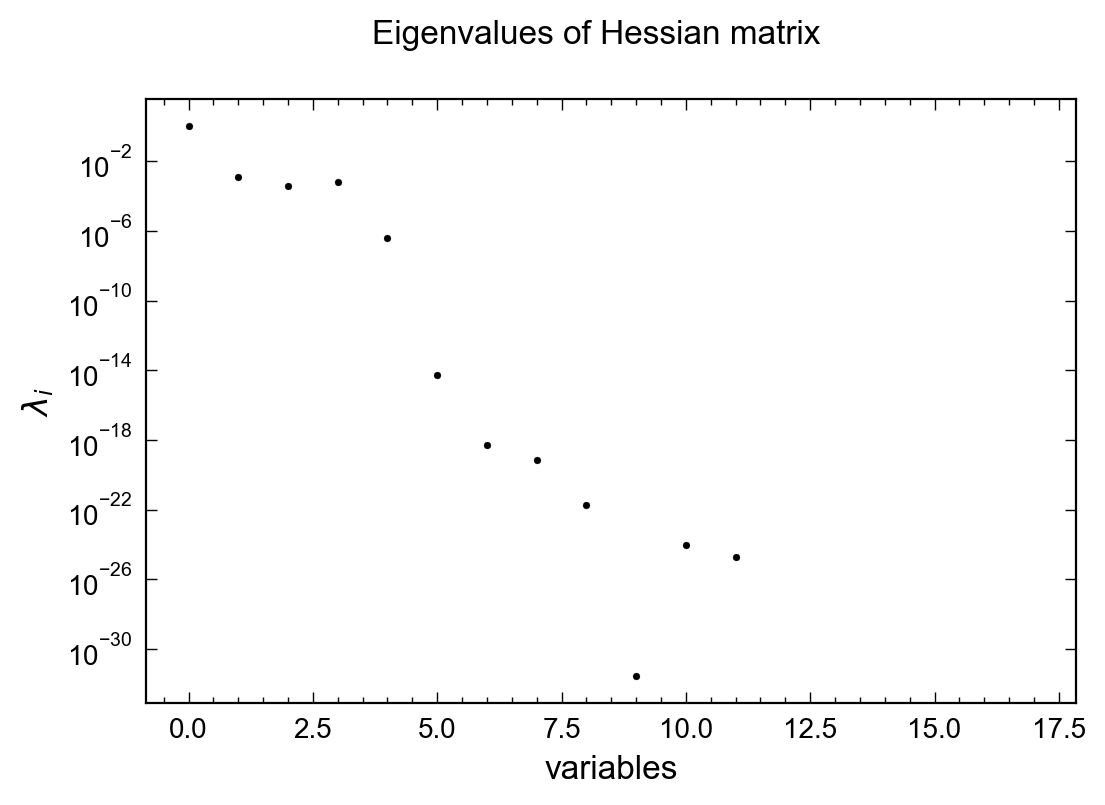

In [12]:
# Compute Hessian and plot eigenvalues
H_sloppy = np.zeros((n_sloppy,n_sloppy))
sigma_H = [np.amax(E),np.amax(cM+eM)]

for i in range(n_sloppy):
    for j in range(n_sloppy):
        H_sloppy[i,j] = (dt/(2*duration))*(np.sum(sloppy_E[:,i]*sloppy_E[:,j])/sigma_H[0]**2 + np.sum(sloppy_M[:,i]*sloppy_M[:,j])/sigma_H[1]**2)
    
H_eigs, H_evecs = np.linalg.eig(H_sloppy)

#print(np.real(H_eigs))
plt.figure(1)
plt.plot(np.real(H_eigs)/np.amax(np.real(H_eigs)),'k.')
plt.semilogy()

plt.xlabel("variables")
plt.ylabel(r"$\lambda_i$")

plt.suptitle(r'Eigenvalues of Hessian matrix')

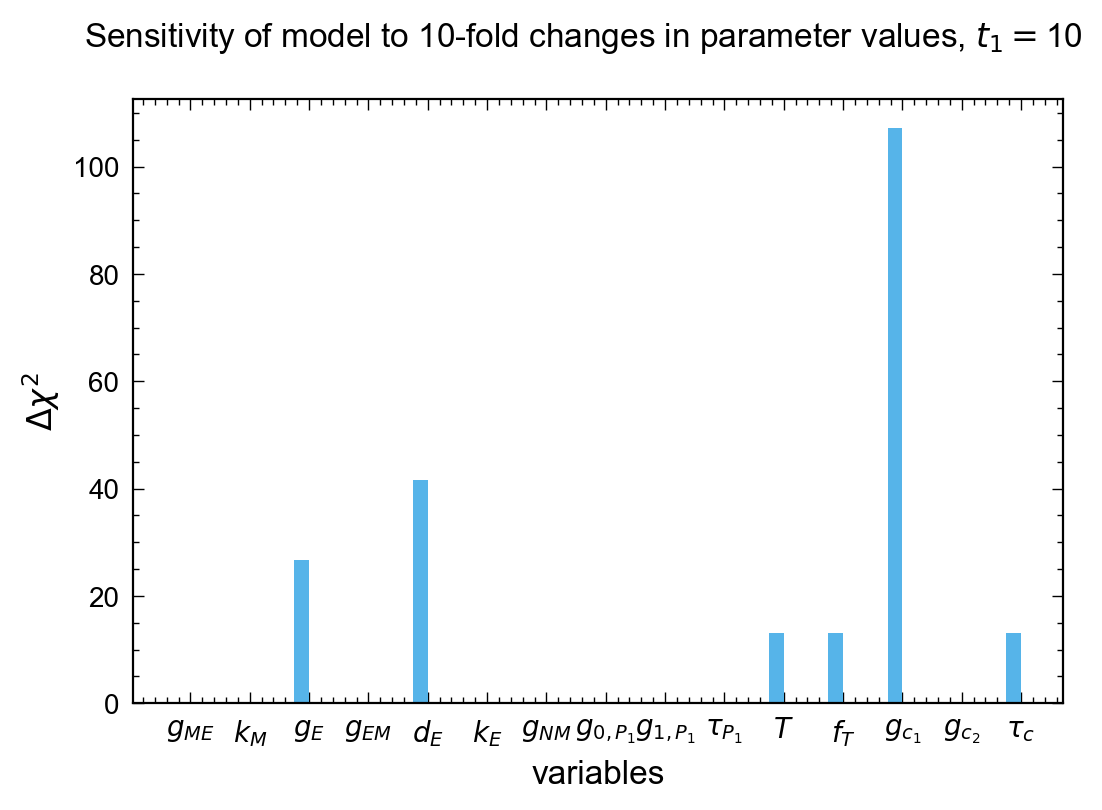

In [13]:
# Identify sloppy 
sloppy_vars = [r"$g_{NE}$", r"$\mu_\theta$", r"$\sigma_\theta$", r"$g_{ME}$", r"$k_M$", r"$g_E$", r"$g_{EM}$", r"$d_E$", r"$k_E$",\
    r"$g_{NM}$", r"$g_{0,P_1}$", r"$g_{1,P_1}$", r"$\tau_{P_1}$", r"$T$", r"$f_T$", r"$g_{c_1}$", r"$g_{c_2}$", r"$\tau_c$"]

plt.figure(1)

r = np.arange(len(sloppy_vars[3:]))
width = 0.25
plt.bar(r, np.diag(H_sloppy)[3:]/2, width = width)

plt.xlabel("variables")
plt.ylabel(r"$\Delta \chi^2$")
#plt.semilogy()

plt.xticks(r + width/2, sloppy_vars[3:])

plt.suptitle(r'Sensitivity of model to 10-fold changes in parameter values, $t_1 =$'+str(t1))
plt.savefig('sloppy-model-analysis-t1-'+str(t1)+'.png', dpi=150)

In [14]:
np.diag(H_sloppy)[4:]/2

array([0.00000000e+00, 2.66222058e+01, 1.34214293e-02, 4.15954682e+01,
       7.68999665e-17, 1.37723663e-01, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 1.31161193e+01, 1.31161193e+01, 1.07186008e+02,
       0.00000000e+00, 1.31161193e+01])

## (5) Parallelize simulation runs

In [15]:
# Parallelize simulation runs
def for_parallel(b_a1, t1, d_a1, T_a1):
    # compute state and costate dynamics

    states = solve_ivp(state_dyn, [0, duration], init_state,
                    dense_output=True, args=[b_a1, t1, d_a1, T_a1, P_vec]).sol(ts).T
    
#     states = nbkode.RungeKutta45(state_dyn, t0 = 0, y0 = init_state, 
#                              params = [b_a1, t1, d_a1, T_a1]).run(ts)[1]
    
    a1, N, E, cM, eM, T = states[:,0], states[:,1], states[:,2], states[:,3], states[:,4], states[:,5]
    run_data = [b_a1, t1, d_a1, T_a1, np.sum(a1*dt), np.argmax(a1)*dt, np.max(E), \
                np.argmax(E)*dt, eM[-1]/np.max(E), np.sum(E*dt)]
    return run_data

stat_names = [r"$g_{a_1}$",r"$t_1$",r"$d_{a_1}$",r"$T_{a_1}$",r"$\int a_1 dt$",\
                             r"$T_{a_1}^{max}$", r"$E^{max}$",r"$T_{E}^{max}$",\
                             r"$\frac{M^\infty}{E^{max}}$",r"$\int E dt$"]

In [16]:
# Set global simulation parameters
runs = 100000

In [17]:
# run several simulations varying b_a1
mu_t1 = t1
mu_b_a1 = 4
mu_d_a1 = 0.0072 # proxy for virulence
mu_T_a1 = 10

#b_a1s = np.random.uniform(0, 2*mu_b_a1, size = runs) 
b_a1s = np.abs(np.random.normal(loc = mu_b_a1, scale = mu_b_a1/np.sqrt(12), size = runs))
t1s = [mu_t1]
d_a1s = [mu_d_a1]
T_a1s = [mu_T_a1]

run_data_b_a1 = np.array(Parallel(n_jobs=os.cpu_count(), batch_size=int(len(b_a1s)/8))(delayed(for_parallel)(b_a1, t1, d_a1, T_a1)
                                              for b_a1 in b_a1s
                                              for t1 in t1s
                                              for d_a1 in d_a1s
                                              for T_a1 in T_a1s))

In [18]:
# run several simulations varying t1
mu_t1 = t1
mu_b_a1 = 4
mu_d_a1 = 0.0072 # proxy for virulence
mu_T_a1 = 10

b_a1s = [mu_b_a1] #np.abs(np.random.normal(loc = mu_b_a1, scale = mu_b_a1, size = runs))

#t1s = np.random.uniform(1, 2*mu_t1, size = runs) 
t1s = np.abs(np.random.normal(loc = mu_t1, scale = mu_t1/np.sqrt(12), size = runs)) # there is a threshold for activation
d_a1s = [mu_d_a1]
T_a1s = [mu_T_a1]

run_data_t1 = np.nan_to_num(np.array(Parallel(n_jobs=os.cpu_count(), batch_size=int(len(t1s)/8))(delayed(for_parallel)(b_a1, t1, d_a1, T_a1)
                                              for b_a1 in b_a1s
                                              for t1 in t1s
                                              for d_a1 in d_a1s
                                              for T_a1 in T_a1s)))

In [19]:
# run several simulations varying d_a1
mu_t1 = t1
mu_b_a1 = 4
mu_d_a1 = 0.0072 # proxy for virulence
mu_T_a1 = 10

b_a1s = [mu_b_a1] #np.abs(np.random.normal(loc = mu_b_a1, scale = mu_b_a1, size = runs))

#t1s = np.random.uniform(1, 2*mu_t1, size = runs) 
t1s = [mu_t1]
d_a1s = np.abs(np.random.normal(loc = mu_d_a1, scale = mu_d_a1/np.sqrt(12), size = runs))
T_a1s = [mu_T_a1]

run_data_d_a1 = np.array(Parallel(n_jobs=os.cpu_count(), batch_size=int(len(d_a1s)/8))(delayed(for_parallel)(b_a1, t1, d_a1, T_a1)
                                              for b_a1 in b_a1s
                                              for t1 in t1s
                                              for d_a1 in d_a1s
                                              for T_a1 in T_a1s))

In [20]:
# run several simulations varying T_a1
mu_t1 = t1
mu_b_a1 = 4
mu_d_a1 = 0.0072 # proxy for virulence
mu_T_a1 = 10

b_a1s = [mu_b_a1]
#t1s = np.random.uniform(1, 2*mu_t1, size = runs) 
t1s = [mu_t1]
d_a1s = [mu_d_a1]
T_a1s = np.abs(np.random.normal(loc = mu_T_a1, scale = mu_T_a1/np.sqrt(12), size = runs))

run_data_T_a1 = np.array(Parallel(n_jobs=os.cpu_count(), batch_size=int(len(T_a1s)/8))(delayed(for_parallel)(b_a1, t1, d_a1, T_a1)
                                              for b_a1 in b_a1s
                                              for t1 in t1s
                                              for d_a1 in d_a1s
                                              for T_a1 in T_a1s))

## (6) Plot distribution of response statistics from simulations varying $g_{a_1}$ and $t_1$

In [21]:
# # Plot summary statistics for b_a1
# fig_b_a1, axs = plt.subplots(5, 2, dpi = 150, constrained_layout=True, figsize=(8,10))
# i = 0
# for ax, val in zip(axs.flat,stat_names):

#     cs = ax.hist(run_data_b_a1[:,i],bins = "auto")
#     ax.set_title(val)
        
#     i += 1

# fig_b_a1.suptitle(r'Features of the infection response while varying $g_{a_1}$ (Gaussian)')
# plt.show()
# fig_b_a1.savefig('response-varying-b_a1-gauss.png', dpi=150)

In [22]:
# # Plot summary statistics for t1
# fig_t1, axs = plt.subplots(4, 2, dpi = 150, constrained_layout=True, figsize=(8,10))
# i = 0
# for ax, val in zip(axs.flat,stat_names):

#     cs = ax.hist(run_data_t1[:,i],bins = "auto")
#     ax.set_title(val)
        
#     i += 1

# fig_t1.suptitle(r'Features of the infection response while varying $t_1$')
# plt.show()
# fig_t1.savefig('response-varying-t1-gauss.png', dpi=150)

### (7) Compute correlations in data

In [23]:
# # Compute correlations and make plots
# corr_b_a1 = np.corrcoef(run_data_b_a1, rowvar = False)
# corr_t1 = np.corrcoef(run_data_t1, rowvar = False)
# corr_d_a1 = np.corrcoef(run_data_d_a1, rowvar = False)
# corr_T_a1 = np.corrcoef(run_data_T_a1, rowvar = False)

# plt.figure(1)

# r = 2*np.arange(len(corr_b_a1))
# width = 0.25
# plt.bar(r, corr_b_a1[:,0], width = width, label = r'vary $g_{a_1}$')
# plt.bar(r + width, corr_t1[:,1], width = width, label = r'vary $t_1$')
# plt.bar(r + 2*width, corr_d_a1[:,2], width = width, label = r'vary $d_{a_1}$')
# plt.bar(r + 3*width, corr_T_a1[:,3], width = width, label = r'vary $T_{a_1}$')

# plt.xlabel("response")
# plt.ylabel("pearson correlation")

# plt.xticks(r + 3*width/2,stat_names)

# plt.legend()
# plt.suptitle(r'Correlations between $g_{a_1}, t_1, d_{a_1}, T_{a_1}$ (Gaussian) respectively and response features')
# plt.savefig('response-corr-gauss.png', dpi=150)

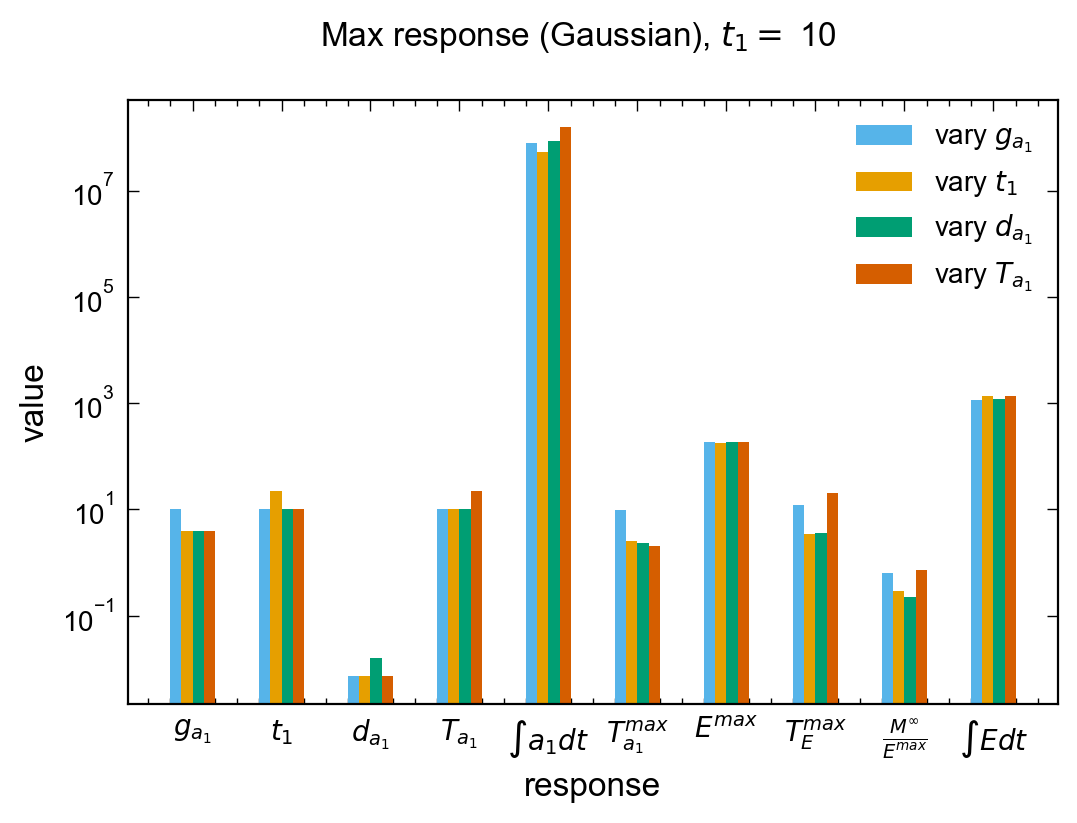

In [24]:
# Compute max values in the data
r = 2*np.arange(len(stat_names))
width = 0.25
plt.bar(r, np.amax(run_data_b_a1, axis = 0), width = width, label = r'vary $g_{a_1}$')
plt.bar(r + width, np.amax(run_data_t1, axis = 0), width = width, label = r'vary $t_1$')
plt.bar(r + 2*width, np.amax(run_data_d_a1, axis = 0), width = width, label = r'vary $d_{a_1}$')
plt.bar(r + 3*width, np.amax(run_data_T_a1, axis = 0), width = width, label = r'vary $T_{a_1}$')

plt.xlabel("response")
plt.ylabel("value")

plt.xticks(r + 3*width/2,stat_names)

plt.semilogy()
plt.legend()
plt.suptitle(r'Max response (Gaussian), $t_1=$ '+str(mu_t1))
plt.savefig('response-max-gauss-t1-'+str(mu_t1)+'.png', dpi=150)

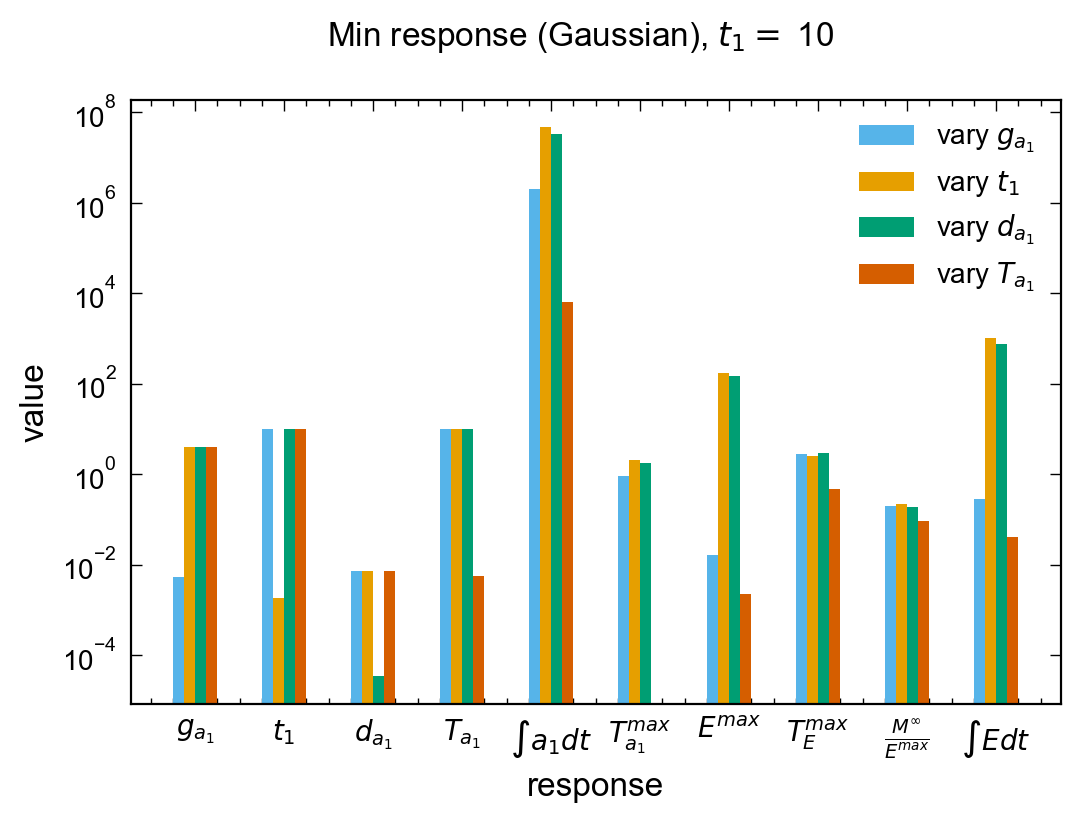

In [25]:
# Compute minimum values in the data
r = 2*np.arange(len(stat_names))
width = 0.25
plt.bar(r, np.amin(run_data_b_a1, axis = 0), width = width, label = r'vary $g_{a_1}$')
plt.bar(r + width, np.amin(run_data_t1, axis = 0), width = width, label = r'vary $t_1$')
plt.bar(r + 2*width, np.amin(run_data_d_a1, axis = 0), width = width, label = r'vary $d_{a_1}$')
plt.bar(r + 3*width, np.amin(run_data_T_a1, axis = 0), width = width, label = r'vary $T_{a_1}$')

plt.xlabel("response")
plt.ylabel("value")

plt.xticks(r + 3*width/2,stat_names)

plt.semilogy()
plt.legend()
plt.suptitle(r'Min response (Gaussian), $t_1=$ '+str(mu_t1))
plt.savefig('response-min-gauss-t1-'+str(mu_t1)+'.png', dpi=150)

### (8) Compute mutual information between variables

In [26]:
# define basic mutual information function
from sklearn.metrics import mutual_info_score

def calc_MI(x, y):
    bx = np.histogram_bin_edges(x, bins="auto", range=None, weights=None)
    by = np.histogram_bin_edges(y, bins="auto", range=None, weights=None)
    
    c_xy = np.histogram2d(x, y, [bx,by])[0]
    mi = mutual_info_score(None, None, contingency=c_xy)/np.log(2)
    return mi

In [27]:
# compute mutual information
MI_b_a1 = np.zeros(run_data_b_a1.shape[1])
for i in range(run_data_b_a1.shape[1]):
    MI_b_a1[i] = calc_MI(run_data_b_a1[:,0],run_data_b_a1[:,i])

MI_t1 = np.zeros(run_data_t1.shape[1])
for i in range(run_data_t1.shape[1]):
    MI_t1[i] = calc_MI(run_data_t1[:,1],run_data_t1[:,i])
    
MI_d_a1 = np.zeros(run_data_d_a1.shape[1])
for i in range(run_data_d_a1.shape[1]):
    MI_d_a1[i] = calc_MI(run_data_d_a1[:,2],run_data_d_a1[:,i])
    
MI_T_a1 = np.zeros(run_data_T_a1.shape[1])
for i in range(run_data_T_a1.shape[1]):
    MI_T_a1[i] = calc_MI(run_data_T_a1[:,3],run_data_T_a1[:,i])  

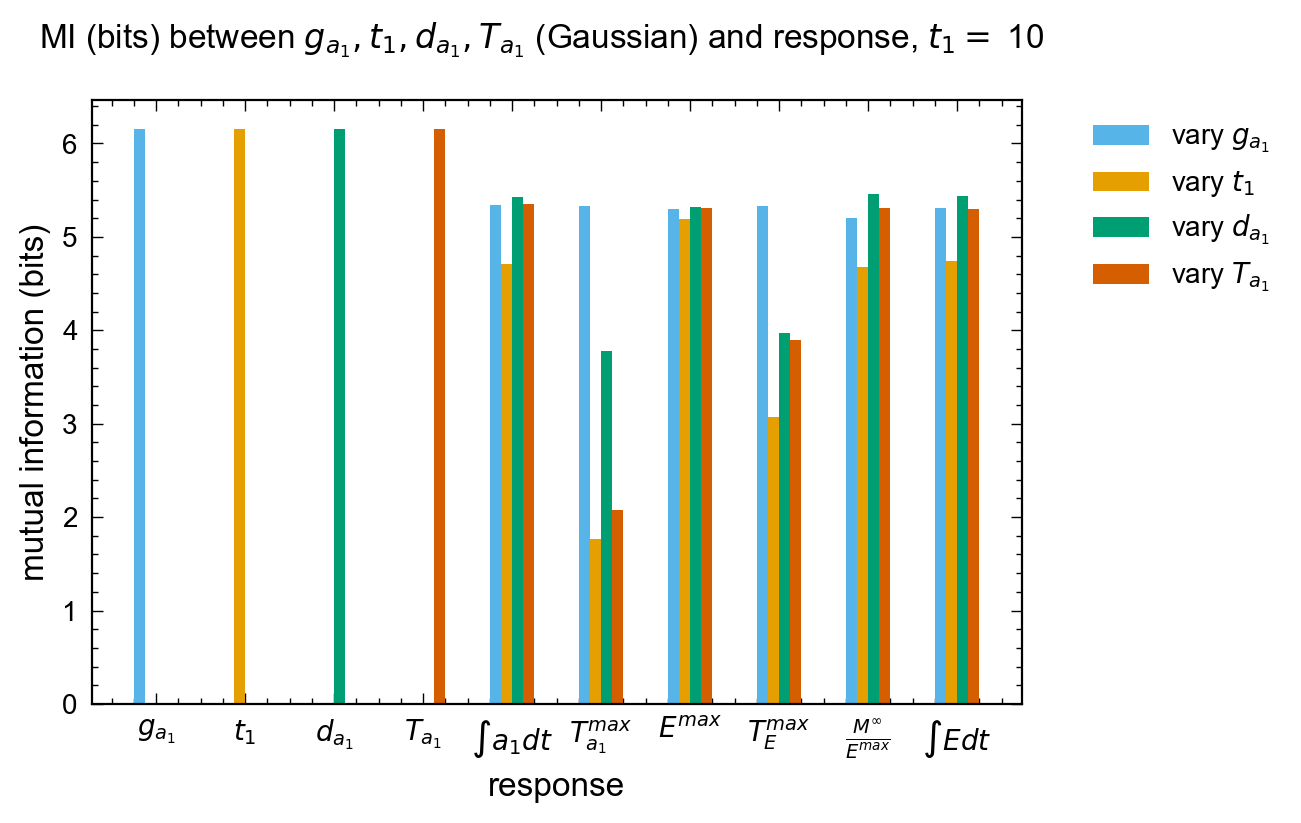

In [28]:
# Plot mutual information
plt.figure(1)

r = 2*np.arange(len(MI_b_a1))
width = 0.25
plt.bar(r, MI_b_a1, width = width, label = r'vary $g_{a_1}$')
plt.bar(r + width, MI_t1, width = width, label = r'vary $t_1$')
plt.bar(r + 2*width, MI_d_a1, width = width, label = r'vary $d_{a_1}$')
plt.bar(r + 3*width, MI_T_a1, width = width, label = r'vary $T_{a_1}$')

plt.xlabel("response")
plt.ylabel("mutual information (bits)")

plt.xticks(r + 3*width/2,stat_names)
#plt.legend()
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.suptitle(r'MI (bits) between $g_{a_1}, t_1, d_{a_1}, T_{a_1}$ (Gaussian) and response, $t_1=$ '+str(mu_t1))
plt.savefig('response-mutual-info-gauss-t1-'+str(mu_t1)+'.png', dpi=150)

## (9) Plot trajectories from simulations

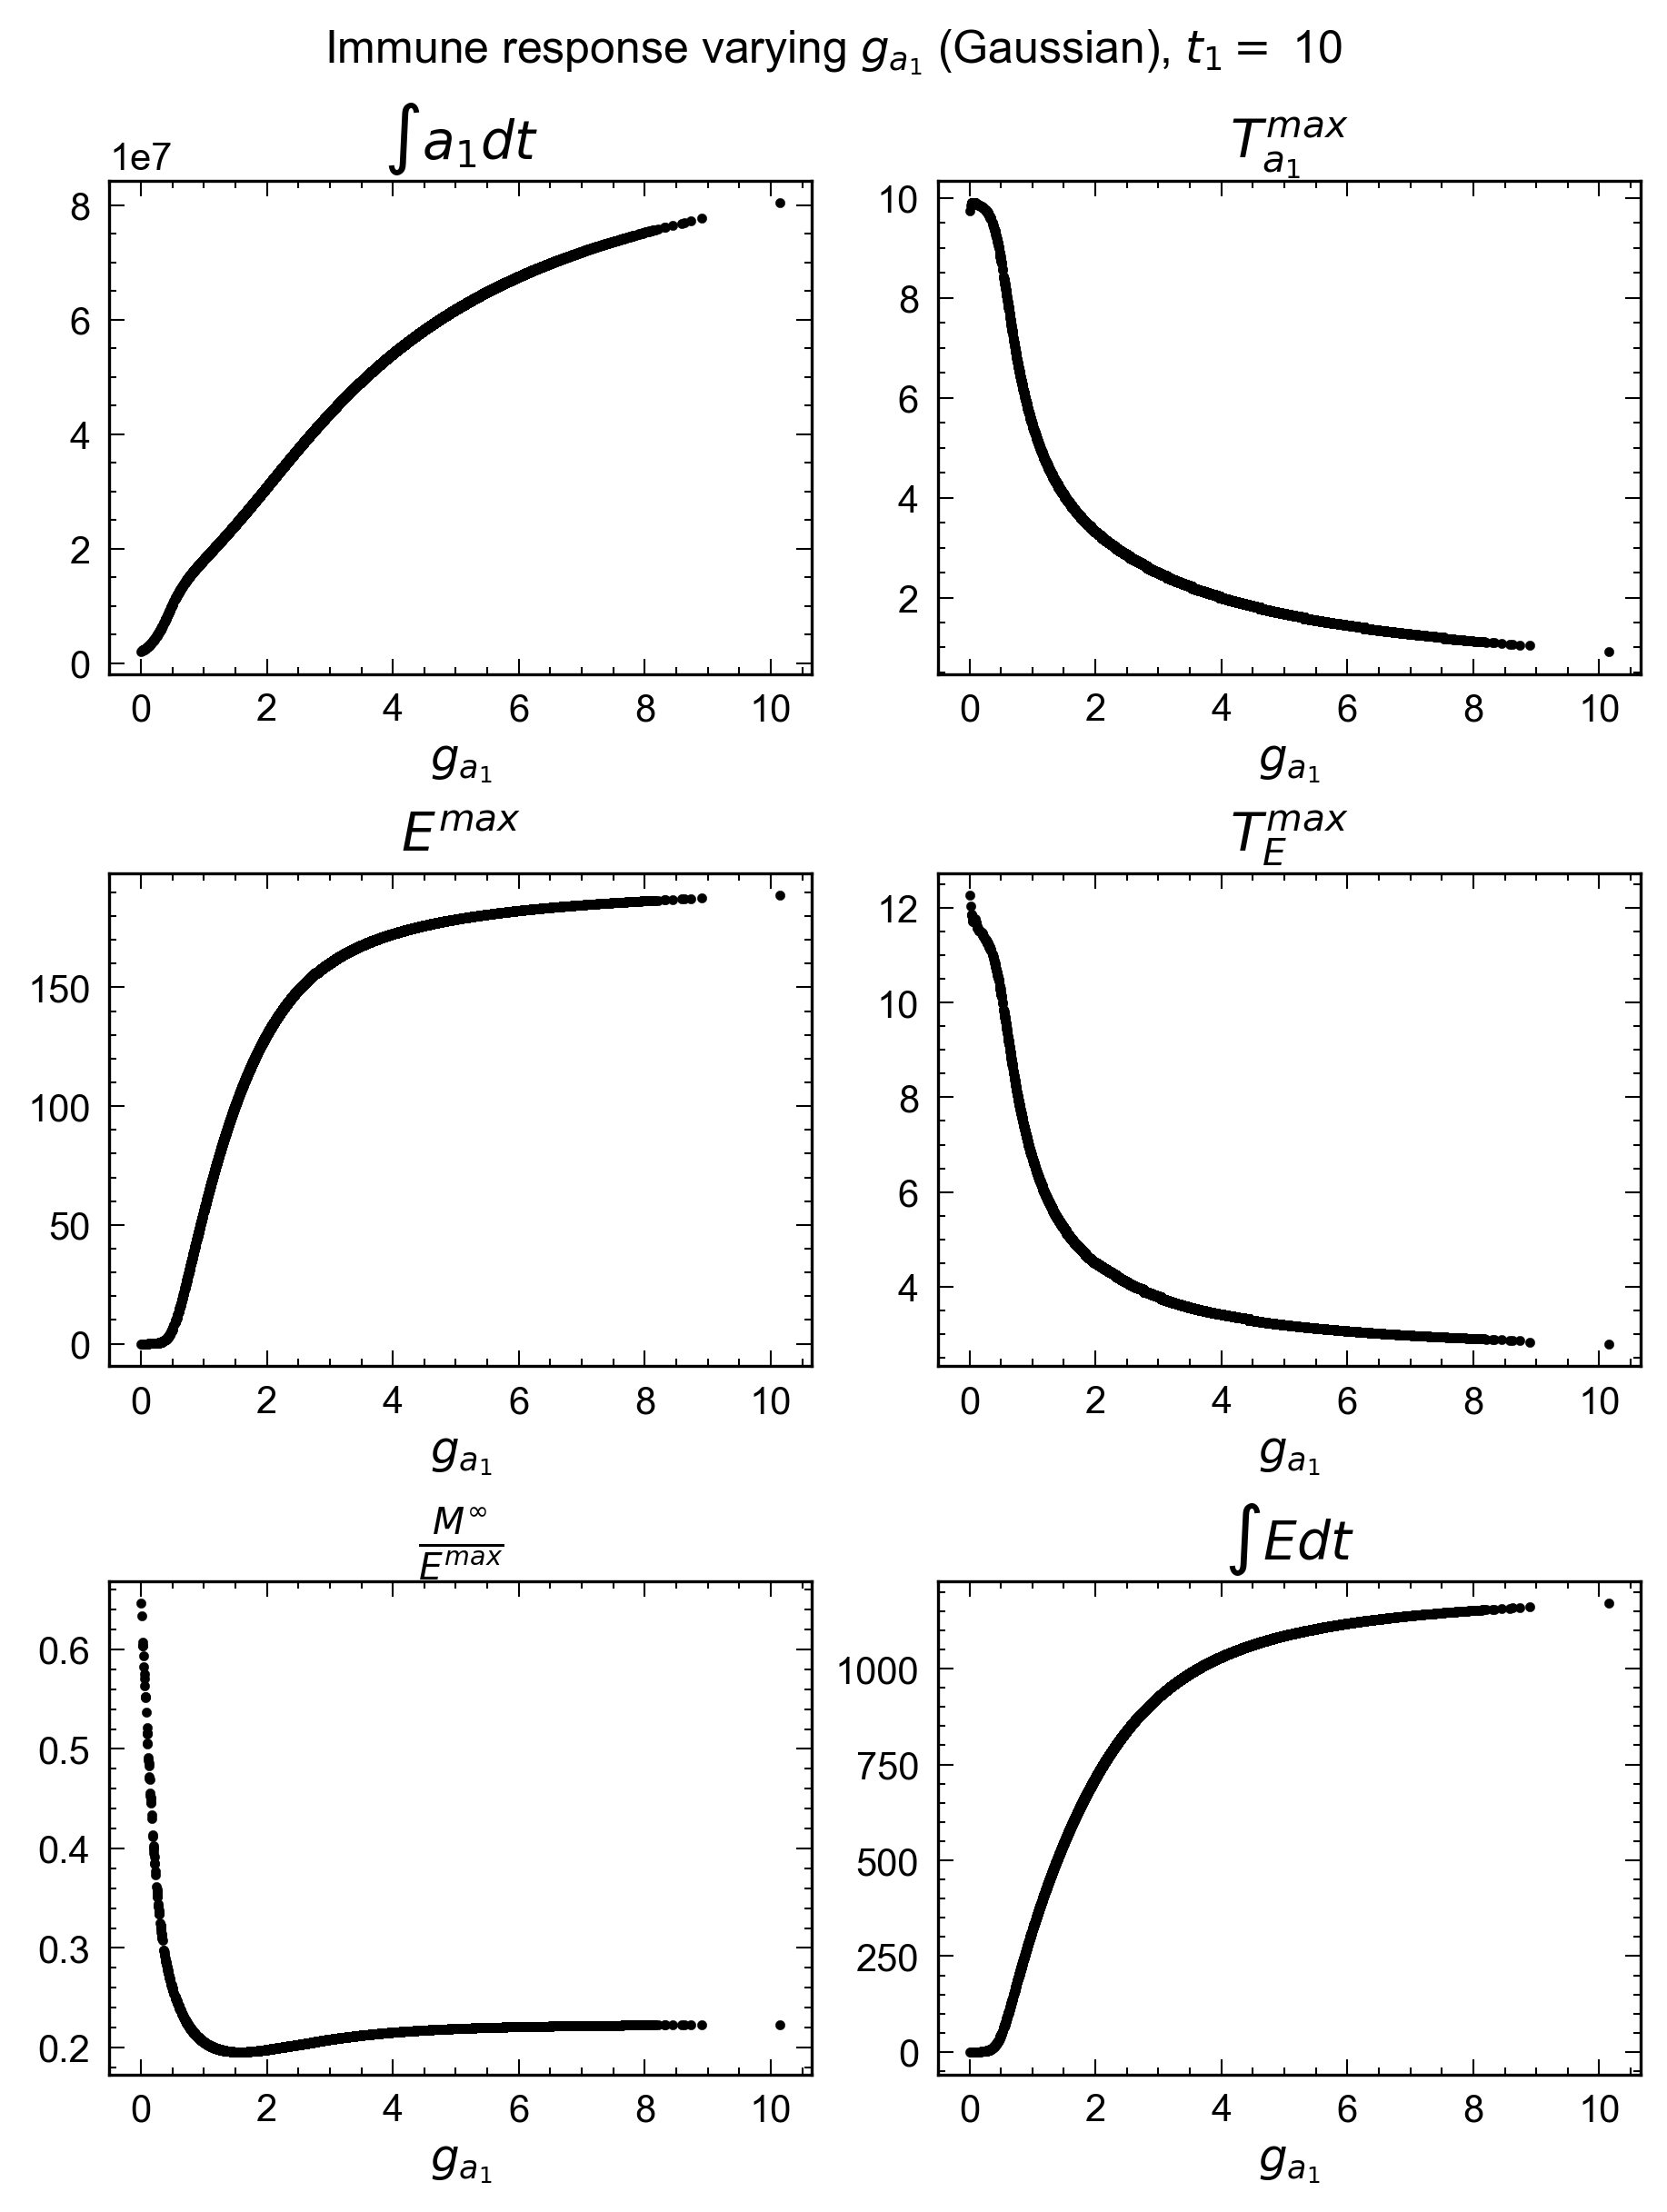

In [29]:
# Plot trajectories for b_a1
fig_b_a1, axs = plt.subplots(3, 2, dpi = 150, constrained_layout=True, figsize=(6,8))
i = 4
for ax, val in zip(axs.flat,stat_names[i:]):

    cs = ax.plot(run_data_b_a1[:,0],run_data_b_a1[:,i],'k.')
    ax.set_title(val)
    ax.set(xlabel=r'$g_{a_1}$')
        
    i += 1

fig_b_a1.suptitle(r'Immune response varying $g_{a_1}$ (Gaussian), $t_1=$ '+str(mu_t1))
plt.show()
fig_b_a1.savefig('plot-response-varying-b_a1-gauss-t1-'+str(mu_t1)+'.png', dpi=150)

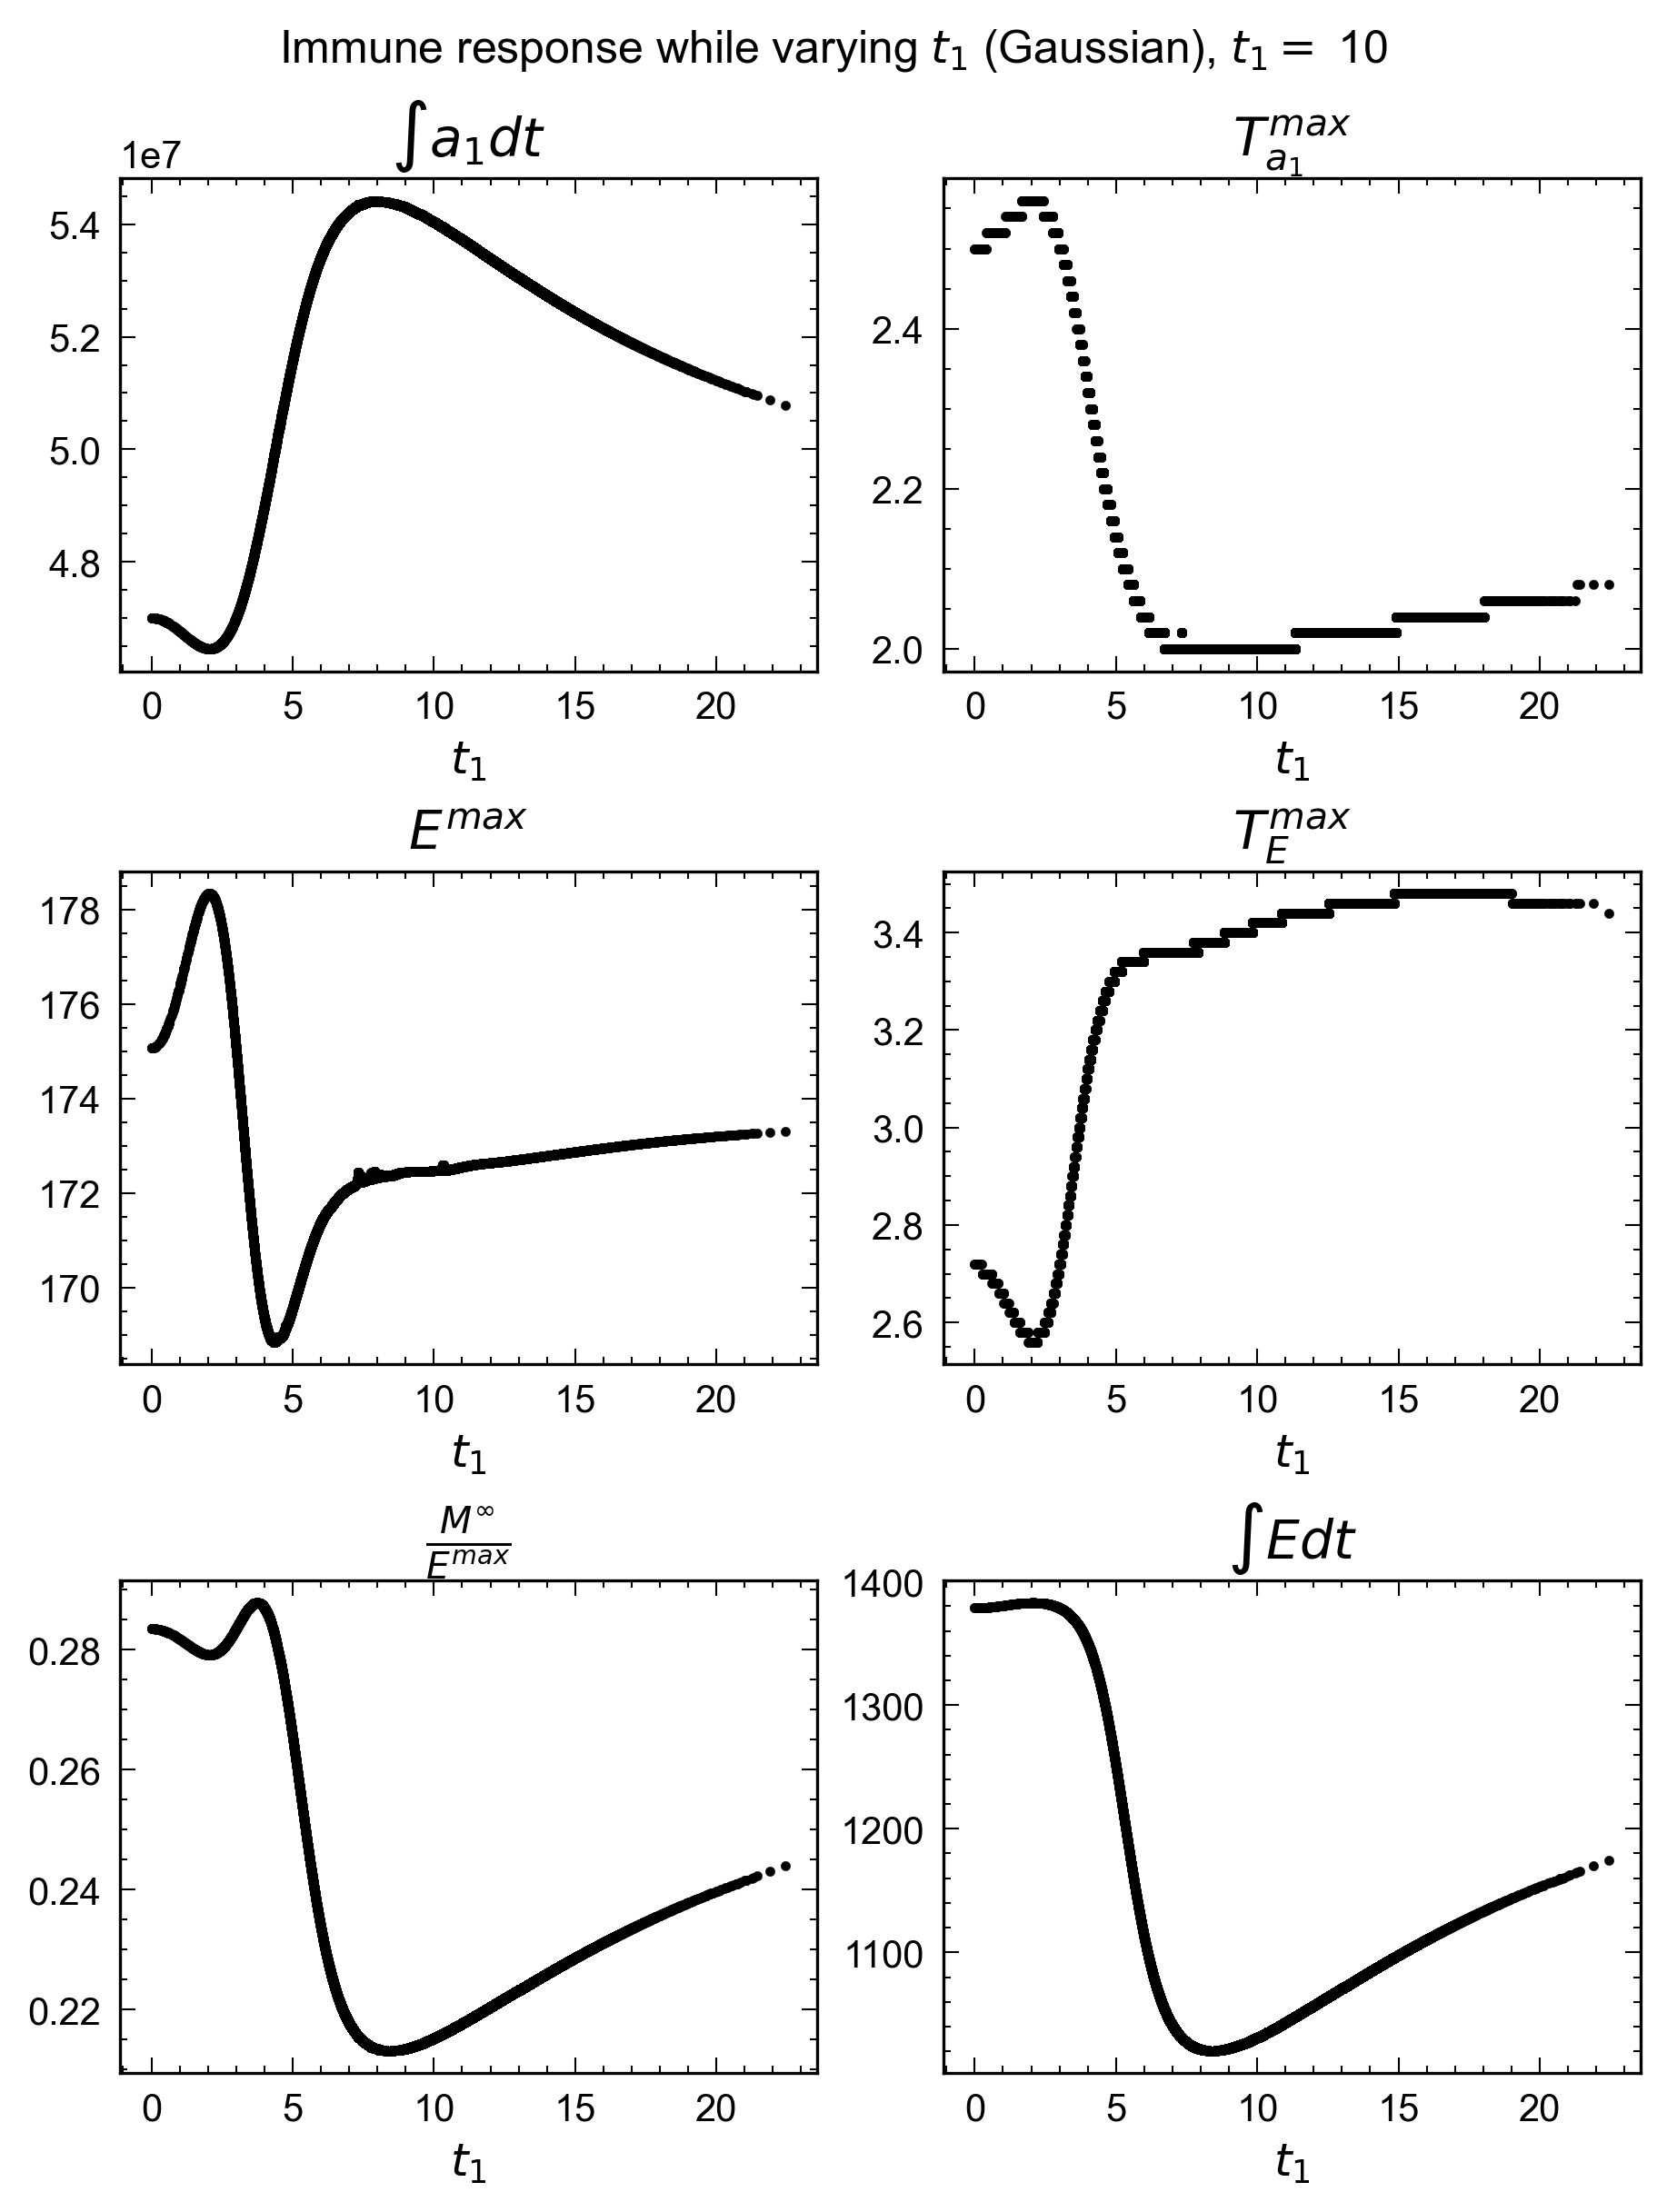

In [30]:
# Plot trajectories for t1
fig_t1, axs = plt.subplots(3, 2, dpi = 150, constrained_layout=True, figsize=(6,8))
i = 4
for ax, val in zip(axs.flat,stat_names[i:]):

    cs = ax.plot(run_data_t1[:,1],run_data_t1[:,i],'k.')
    ax.set_title(val)
    ax.set(xlabel=r'$t_1$')
        
    i += 1

fig_t1.suptitle(r'Immune response while varying $t_1$ (Gaussian), $t_1=$ '+str(mu_t1))
plt.show()
fig_t1.savefig('plot-response-varying-t1-gauss-t1-'+str(mu_t1)+'.png', dpi=150)

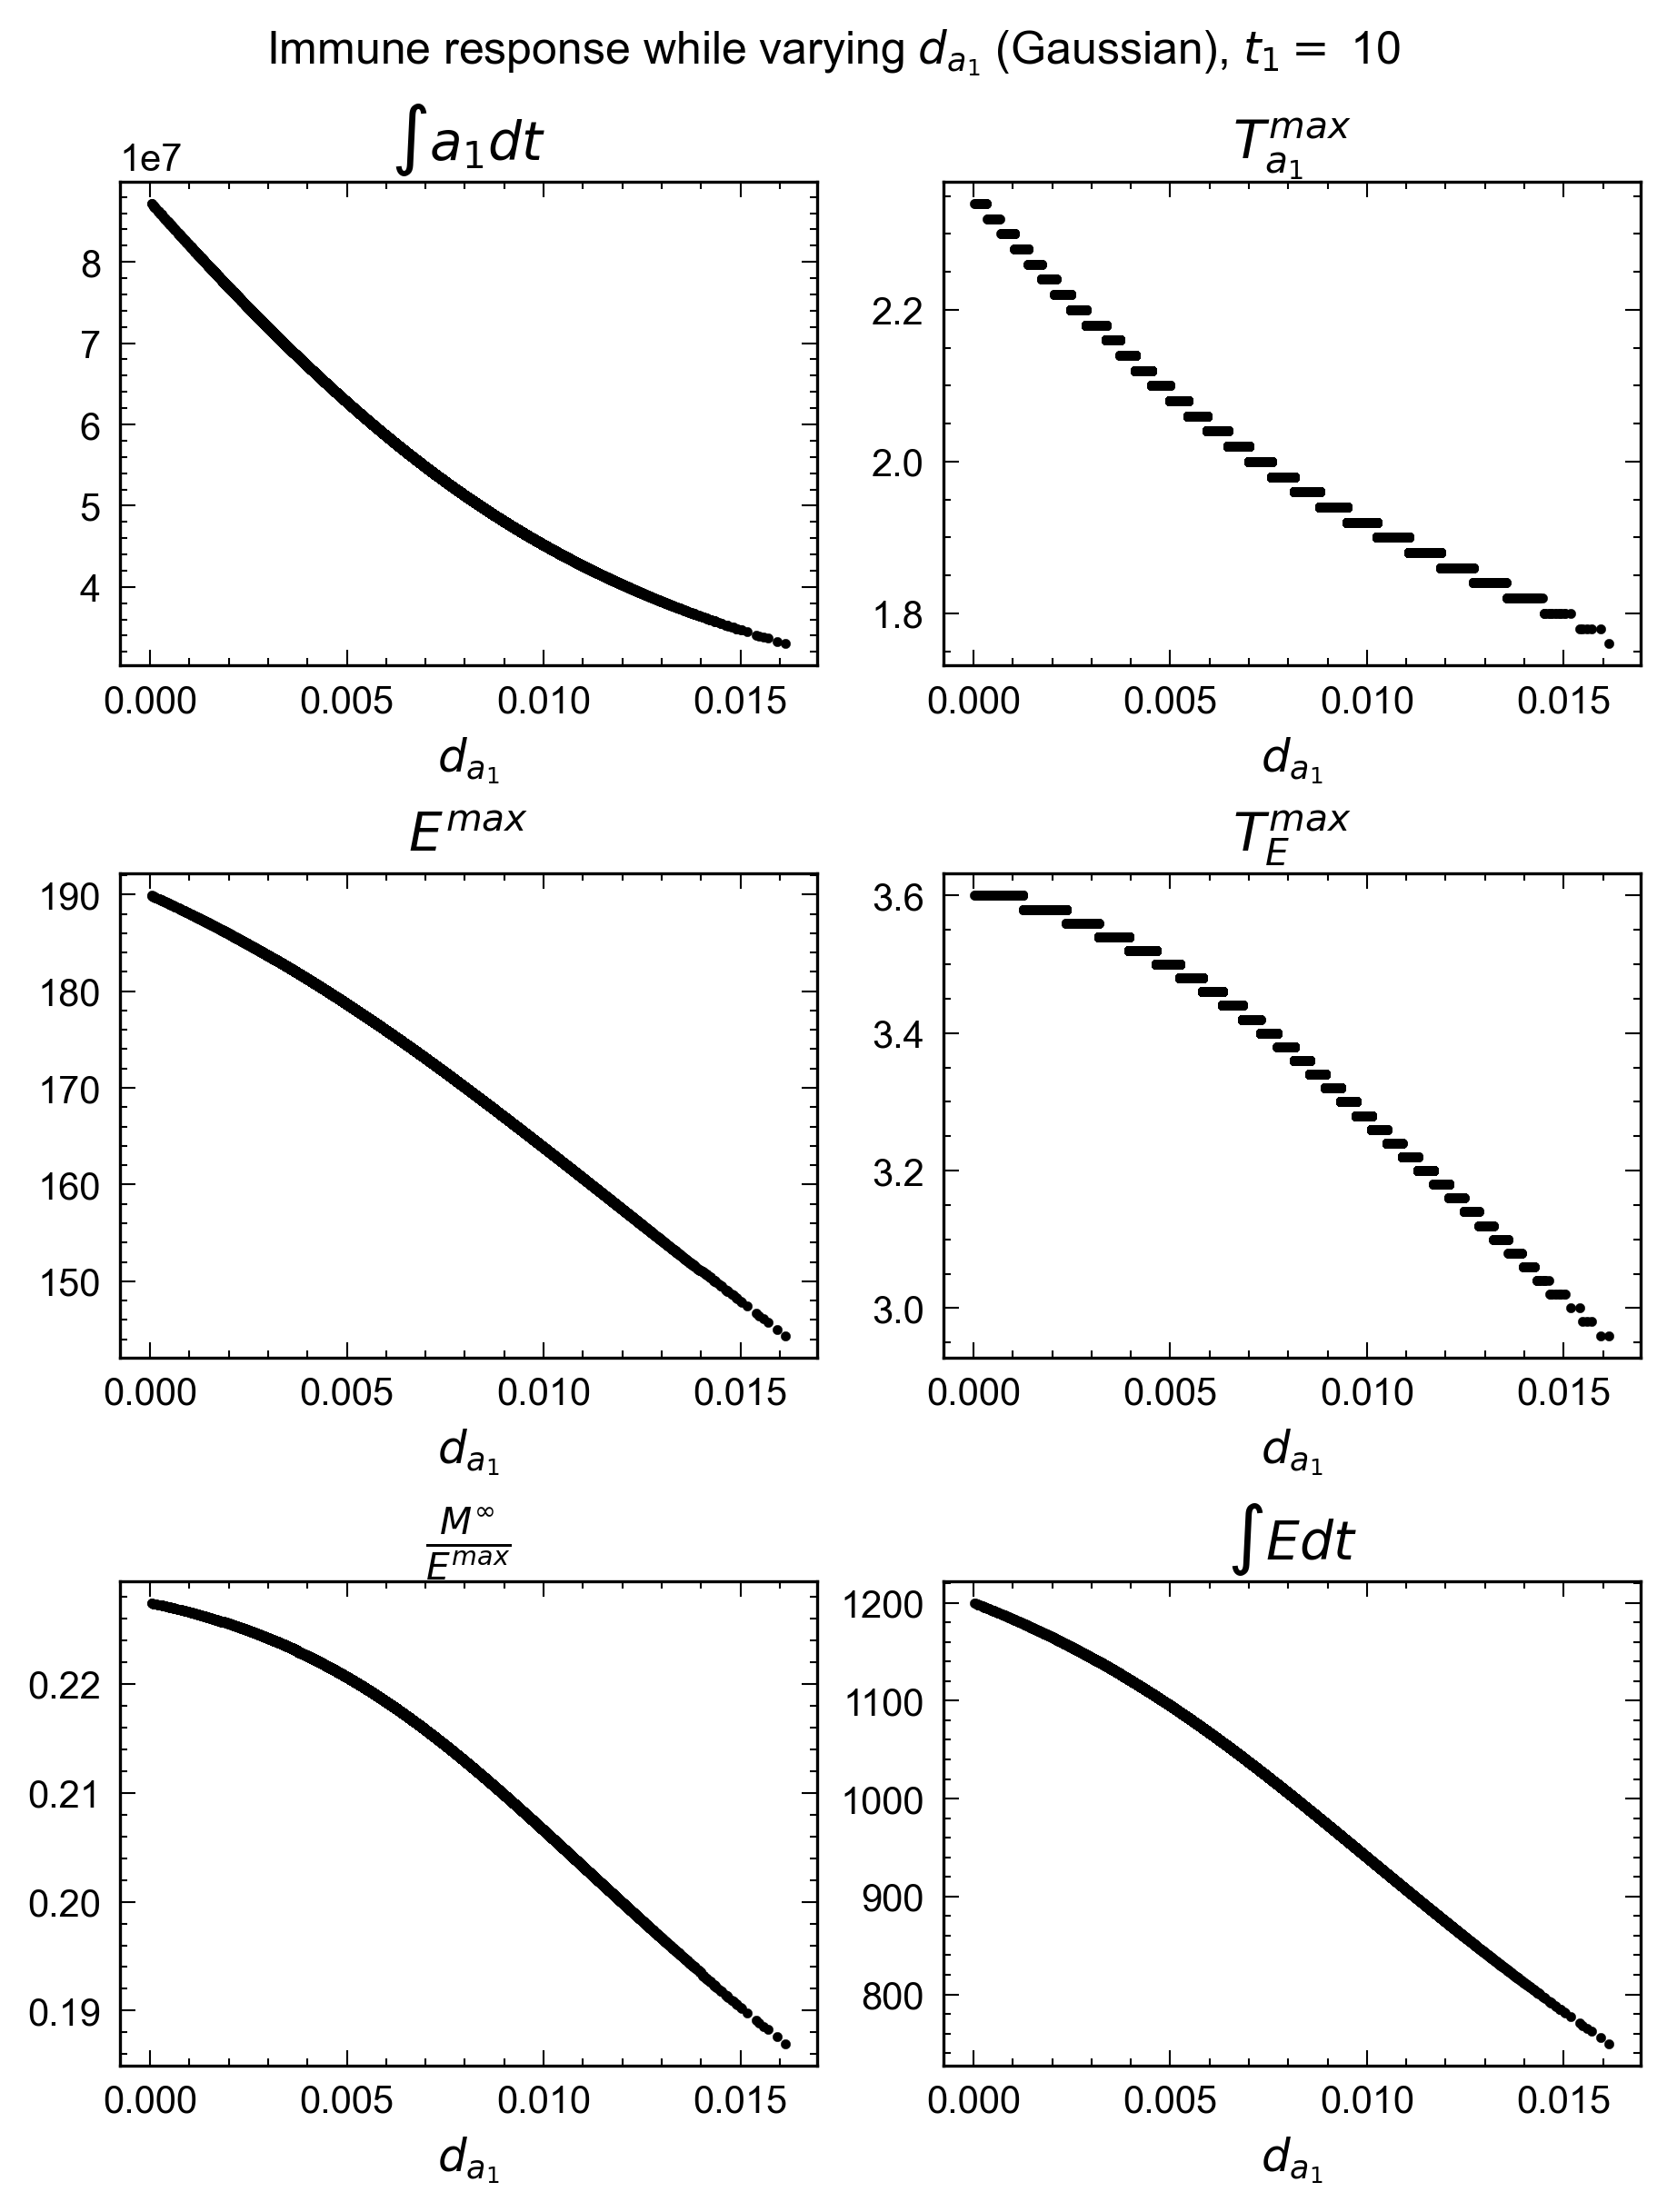

In [31]:
# Plot trajectories for d_a1
fig_t1, axs = plt.subplots(3, 2, dpi = 150, constrained_layout=True, figsize=(6,8))
i = 4
for ax, val in zip(axs.flat,stat_names[i:]):

    cs = ax.plot(run_data_d_a1[:,2],run_data_d_a1[:,i],'k.')
    ax.set_title(val)
    ax.set(xlabel=r'$d_{a_1}$')
        
    i += 1

fig_t1.suptitle(r'Immune response while varying $d_{a_1}$ (Gaussian), $t_1=$ '+str(mu_t1))
plt.show()
fig_t1.savefig('plot-response-varying-d_a1-gauss-t1-'+str(mu_t1)+'.png', dpi=150)

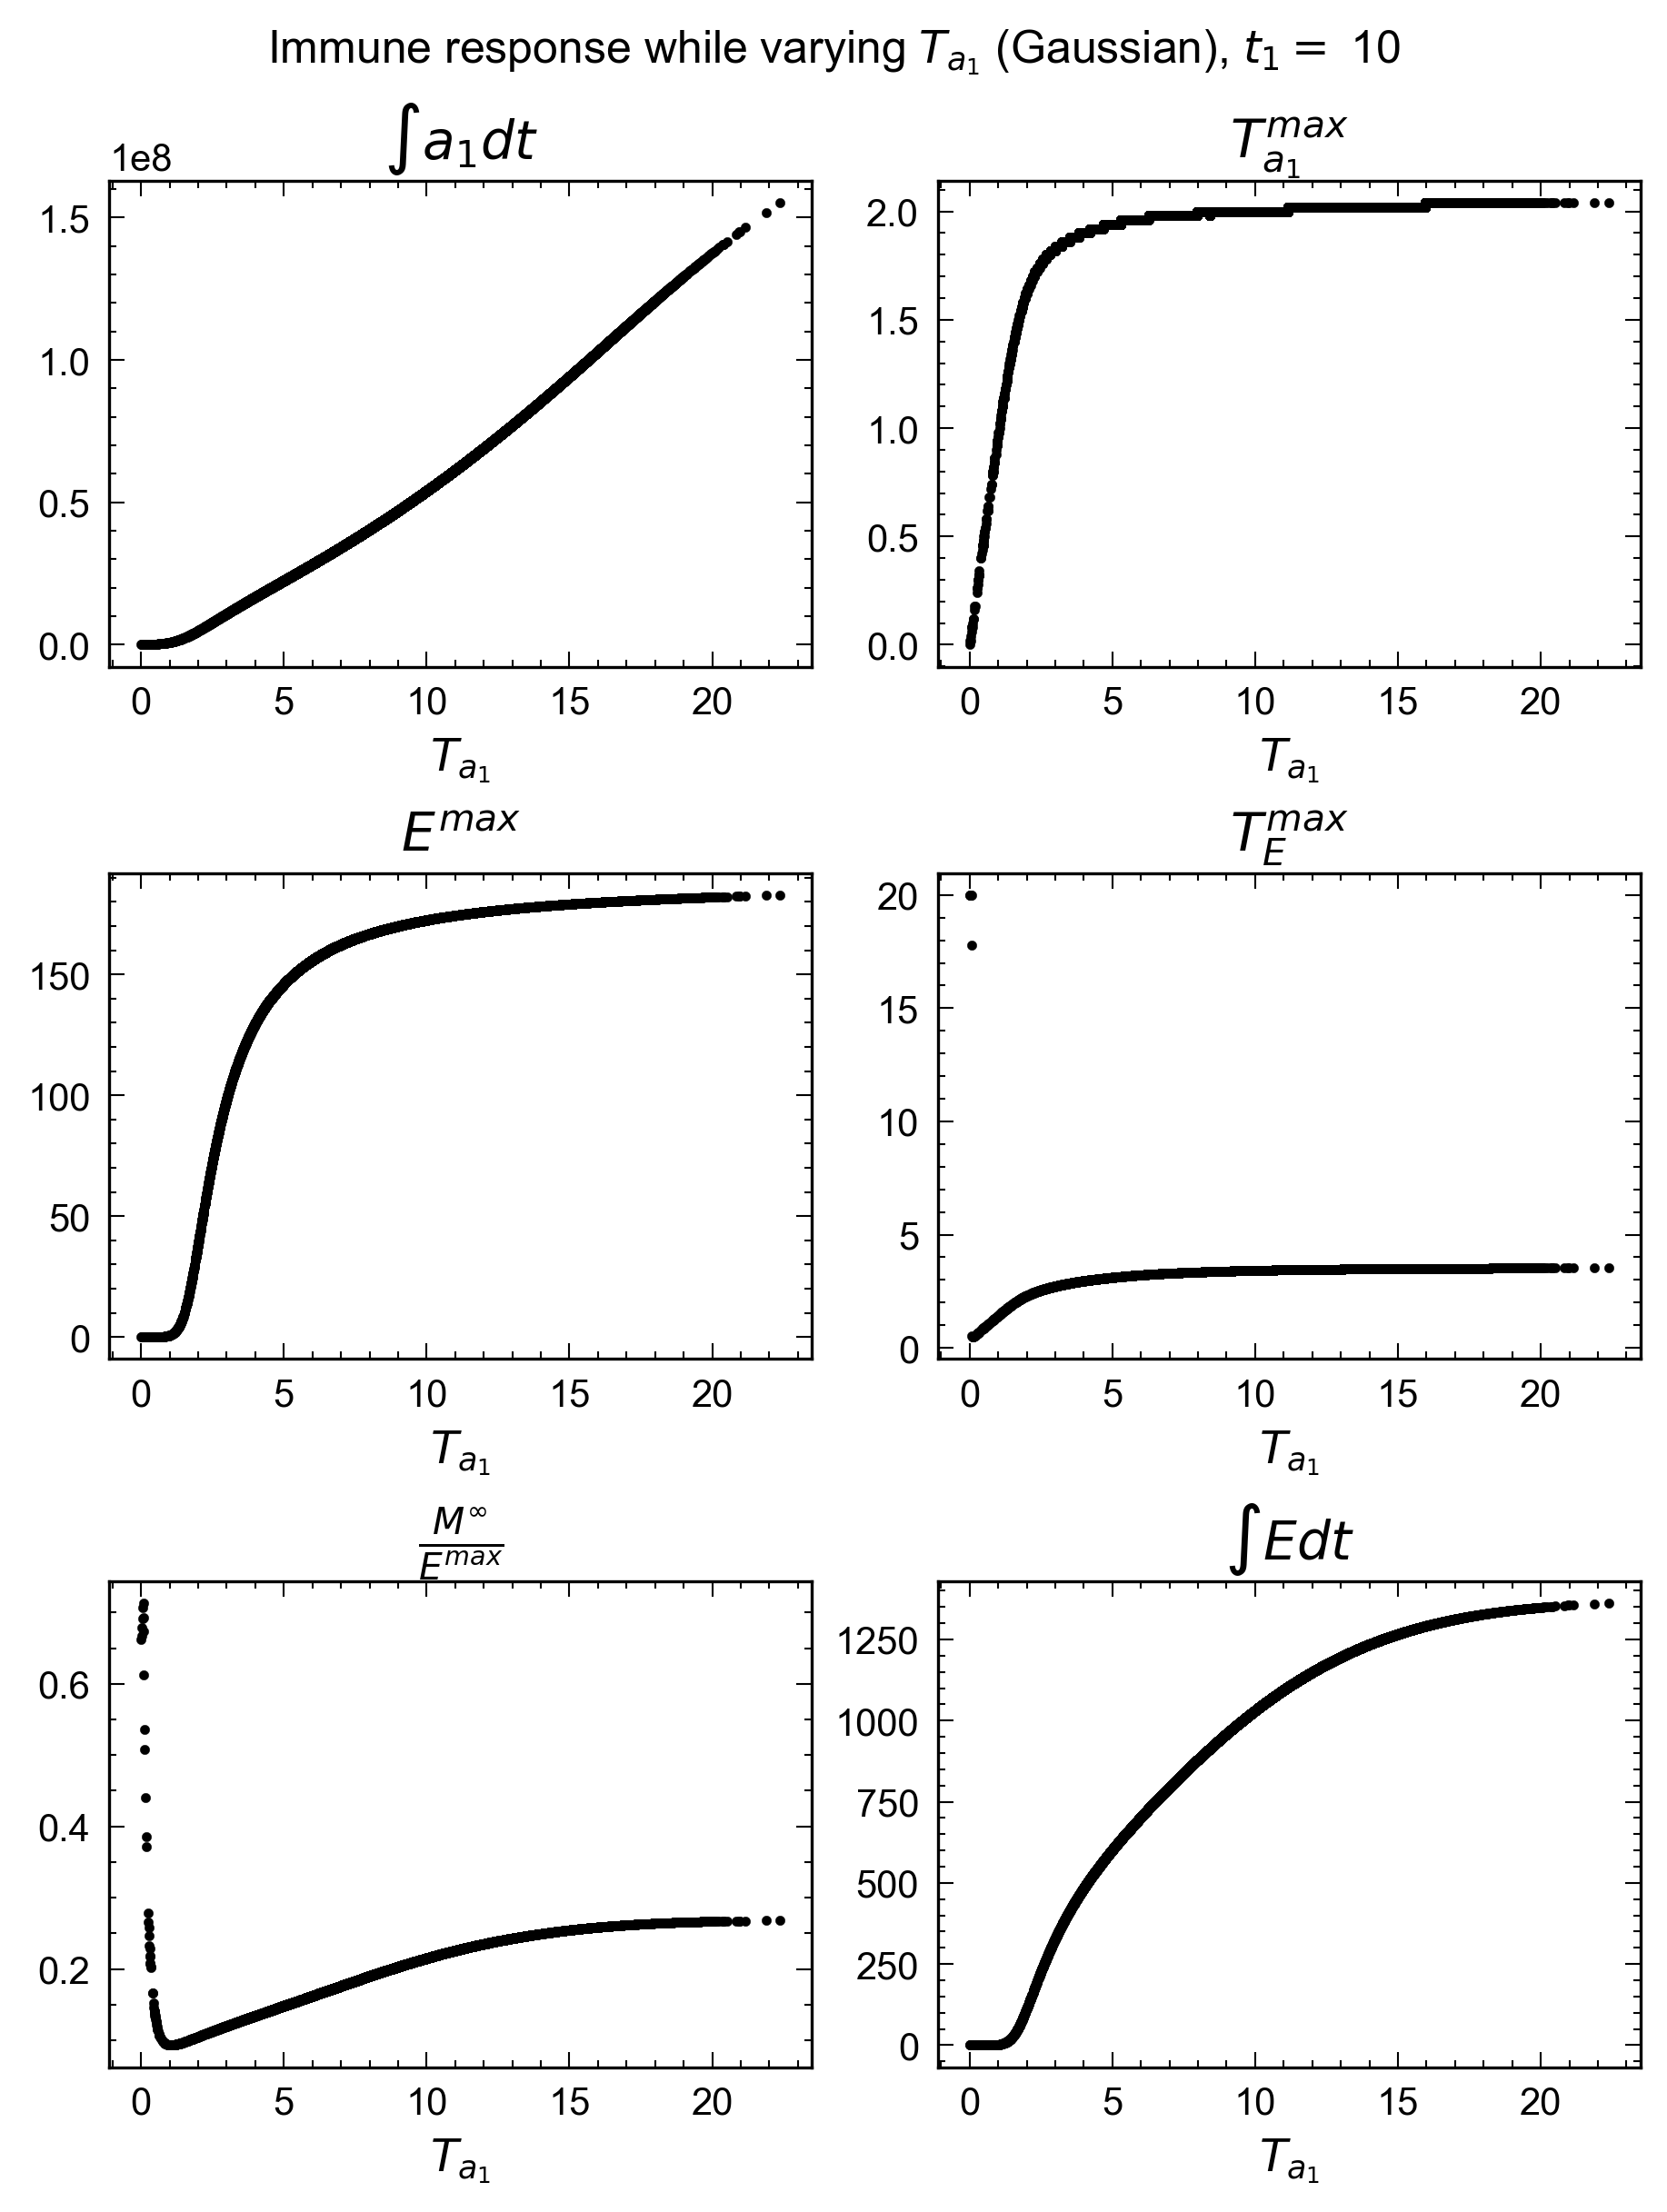

In [32]:
# Plot trajectories for T_a1
fig_t1, axs = plt.subplots(3, 2, dpi = 150, constrained_layout=True, figsize=(6,8))
i = 4
for ax, val in zip(axs.flat,stat_names[i:]):

    cs = ax.plot(run_data_T_a1[:,3],run_data_T_a1[:,i],'k.')
    ax.set_title(val)
    ax.set(xlabel=r'$T_{a_1}$')
        
    i += 1

fig_t1.suptitle(r'Immune response while varying $T_{a_1}$ (Gaussian), $t_1=$ '+str(mu_t1))
plt.show()
fig_t1.savefig('plot-response-varying-T_a1-gauss-t1-'+str(mu_t1)+'.png', dpi=150)